In [7]:
import os, sys, json
import matplotlib.pyplot as plt
import numpy as np
sys.path.append("..")
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

cdf_file = "../../../config/trace/Facebook_CacheFollowerDist_IntraCluster.txt"
figure_name_suffix = "fig10a"

In [8]:
# read cdf_txt and gen flow_size_group
flow_size_group = []
traffics = []
cdfs = []
xticklabels = []
with open(cdf_file, "r") as f:
    for line in f.readlines():
        traffic, cdf = line.split(' ')
        traffic, cdf = int(traffic), float(cdf)
        traffics.append(traffic)
        cdfs.append(cdf)

gap = np.linspace(0, 1, 21)
last_size = traffics[0]
last_size_str = str(traffics[0]) + "B"
if last_size >= 1024 and last_size < 1024 * 1024:
    last_size_str = str(round(float(last_size / 1024), 1)) + "KB"
elif last_size >= 1024 * 1024:
    last_size_str = str(round(float(last_size / 1024 / 1024),1)) + "MB"
gap_index = 1;
for index in range(1, len(traffics)):
    if gap_index + 1 >= len(gap):
        temp = {}
        temp["name"] = "(" + last_size_str + ",)"
        temp["size"] = [last_size, 1e9]
        gap_index += 1
        flow_size_group.append(temp)
        xticklabels.append(last_size_str)
        break
        
    if cdfs[index] >= gap[gap_index]:
        temp = {}
        upper = str(traffics[index]) + "B"
        if traffics[index] >= 1024 and traffics[index] < 1024 * 1024:
            upper = str(round(float(traffics[index] / 1024), 1)) + "KB"
        elif traffics[index] >= 1024 * 1024:
            upper = str(round(float(traffics[index] / 1024 / 1024), 1)) + "MB"
        xticklabels.append(upper)
        temp = {}
        temp["name"] = "(" + last_size_str + "," + upper + "]"
        temp["size"] = [last_size, traffics[index]]
        gap_index += 1
        last_size = traffics[index]
        last_size_str = upper
        flow_size_group.append(temp)

In [9]:
# read from json
data = None
figure_name_prefix = "../figures/"
print(figure_name_suffix)

data_path = "../../../output/oscar-nsdi26/experiments/"+figure_name_suffix+"/"
experiment_names = ["oscar", "hpcc", "hpcc-target1.5"] 
experiment_suffix = ""

slowdowns = [[] for i in range(len(experiment_names))]
avg_slowdowns = [[] for i in range(len(experiment_names))]
avg_fcts = [[] for i in range(len(experiment_names))]
p99_slowdowns = [[] for i in range(len(experiment_names))]
p99_fcts = [[] for i in range(len(experiment_names))]

for exp_idx, experiment_name in enumerate(experiment_names):

    with open(data_path + experiment_name + experiment_suffix + ".json", "r") as f:
        data = json.load(f)

    flow_types = [g["name"] for g in flow_size_group]
    flows = [[] for i in range(len(flow_types))]
    for flow in data["flowStatistics"]:
        # find group of the flow by flow size
        for g in flow_size_group:
            if g["name"] == "Incast":
                if flow["flowType"] == "Incast":
                    flows[flow_size_group.index(g)].append(flow)
                    continue
            if flow["totalSizeBytes"] > g["size"][0] and flow["totalSizeBytes"] <= g["size"][1]:
                flows[flow_size_group.index(g)].append(flow)
                # break

    # calculate the fct slowdown according to the data:"flowStatistics":[:]:"totalSizeBytes"
    flow_slowdown = [[] for i in range(len(flow_types))]
    fcts = [[] for i in range(len(flow_types))]
    tor_rtt = 4e3
    pod_rtt = 8e3
    full_rtt = 12e3
    tor_size = 16
    pod_size = 64
    for i in range(len(flow_types)):
        for flow in flows[i]:
            total_size_bytes = flow["totalSizeBytes"]
            fct = flow["fctNs"]
            # calculate the rtt according the ip addr distance
            rtt = 0
            src_ip = flow["flowIdentifier"]["srcAddr"]
            dst_ip = flow["flowIdentifier"]["dstAddr"]
            # convert ip to int
            src_ip = int(src_ip.split(".")[2])*256 + int(src_ip.split(".")[3])
            dst_ip = int(dst_ip.split(".")[2])*256 + int(dst_ip.split(".")[3])
            # calculate the relation between src and dst
            if src_ip // tor_size == dst_ip // tor_size:
                rtt = tor_rtt
            elif src_ip // pod_size == dst_ip // pod_size:
                rtt = pod_rtt
            else:
                rtt = full_rtt
            slowdown = fct / (total_size_bytes * 8 / 100e9 * 1e9 + rtt)
            flow_slowdown[i].append(slowdown)
            fcts[i].append(fct/1e6) # ms

    # calculate the average slowdown and the p99 slowdowns
    avg_slowdown = []
    p99_slowdown = []
    avg_fct = []
    p99_fct = []
    for i in range(len(flow_types)):
        avg_slowdown.append(np.mean(flow_slowdown[i]))
        p99_slowdown.append(np.percentile(flow_slowdown[i], 99))
        avg_fct.append(np.mean(fcts[i]))
        p99_fct.append(np.percentile(fcts[i], 99))
    
    slowdowns[exp_idx] = flow_slowdown
    avg_slowdowns[exp_idx] = avg_slowdown
    p99_slowdowns[exp_idx] = p99_slowdown
    avg_fcts[exp_idx] = avg_fct
    p99_fcts[exp_idx] = p99_fct

fig10a


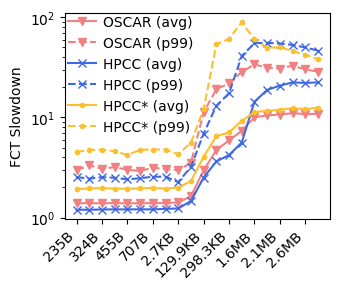

In [11]:

hatches = ['', '/', 'x', '-', '//', '+', '\\', '|', '*', '+', '-', '/']
colors = ['#f18181', '#4068e1', '#FBC02D', '#c198b3', '#0097A7', '#a9a9a9', '#512DA8',
          '#00bfff', '#228b22']  
markers = ['v', 'x', '.']
# plot the line figure of average slowdown and p99 slowdown in one figure
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3))

num_groups = 3
num_bars_per_group = 6
# width of each bar
bar_width = 0.08

group_positions = np.arange(len(flow_size_group))


index = 0
exp_is = list(range(len(experiment_names)))
labels = ["OSCAR", "HPCC", "HPCC*"]
for bar_idx, i in enumerate(exp_is):
    plt.plot(group_positions, [s for s in avg_slowdowns[i]], label=labels[i] +
             " (avg)", linestyle='-', color=colors[index], marker=markers[index])
    plt.plot(group_positions, [s for s in p99_slowdowns[i]], label=labels[i] +
             " (p99)", linestyle='--', color=colors[index], marker=markers[index])
    index += 1

ax.set_ylabel("FCT Slowdown")
ax.set_xticks(list(group_positions)[::2])
ax.set_xticklabels(xticklabels[::2], rotation=45, ha='right')

ax.set_yscale("log")

plt.legend(loc='center', bbox_to_anchor=(0.25, 0.7), ncol=1,
           frameon=False, prop={'size': 10}, handleheight=0.9, handletextpad=0.5)

plt.tight_layout()

# save as pdf
plt.savefig(figure_name_prefix + figure_name_suffix +
            ".pdf", bbox_inches='tight', dpi=600, format='pdf')